# 04 - Baseline Model (Day-Based Split)

**Day 1 - Cross-Temporal Hybrid NIDS**

Trains and evaluates the Day 1 lightweight Random Forest baseline on the
train/test parquet files produced by `scripts/prepare_data.py`. As of
this update, `prepare_data.py` automatically uses **day-based
(file-identity) splitting** instead of row-level timestamp splitting,
because this dataset variant has no row-level timestamp column (see
`03_temporal_split.ipynb` for the full diagnosis).

`split_metadata.json` now records which split mechanism was actually
used (`"split_method": "capture_day"` vs `"row_timestamp"`) so this is
never ambiguous after the fact. This notebook reads that field and
documents it explicitly rather than assuming.

**Read this before trusting any metric below:** because CIC-IDS2017
attacks are day-specific by design, the train days and test day(s) here
do **not** share the same class/attack-type distribution. A low recall
on an attack type that simply never appeared in training is an expected
consequence of the split, not necessarily a weak model -- report
per-class behavior, not just aggregate metrics, when interpreting
results from this split.

Hyperparameters mirror `scripts/train_baseline.py` exactly (no
hyperparameter tuning, no cross-validation, no SHAP -- out of Day 1
scope).

> **Status:** not executed against real data. Run
> `scripts/prepare_data.py` first.

In [5]:
# --- Setup -----------------------------------------------------------
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    classification_report,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "day1"
MODELS_DIR = PROJECT_ROOT / "models" / "day1"
RESULTS_DIR = PROJECT_ROOT / "results" / "day1"

TRAIN_PATH = PROCESSED_DIR / "train.parquet"
TEST_PATH = PROCESSED_DIR / "test.parquet"
METADATA_PATH = PROCESSED_DIR / "split_metadata.json"

# Lightweight settings for an 8GB RAM, CPU-only machine - mirrors
# scripts/train_baseline.py defaults exactly.
N_ESTIMATORS = 100
MAX_DEPTH = 20
N_JOBS = -1
RANDOM_STATE = 42

## 1. Loading the prepared data and confirming the split method

Loads the split train/test Parquet files plus metadata, and explicitly
checks (rather than assumes) which split mechanism produced them.

In [6]:
for path in (TRAIN_PATH, TEST_PATH, METADATA_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run scripts/prepare_data.py first to "
            "produce the train/test split."
        )

metadata = json.loads(METADATA_PATH.read_text())
feature_names = metadata["feature_names"]
split_method = metadata.get("split_method", "unknown")

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Feature count: {len(feature_names)}")
print(f"Split method : {split_method!r}")
print(f"Leakage check passed: {metadata.get('leakage_check', {}).get('passed')}")

if split_method == "capture_day":
    train_days = metadata["split_summary"]["train_days"]
    test_days = metadata["split_summary"]["test_days"]
    print(f"\nDay-based split: train_days={train_days}, test_days={test_days}")
    print(
        "CAVEAT: CIC-IDS2017 attacks are day-specific by design, so train "
        "and test days do NOT share the same attack-type distribution. "
        "Interpret per-class metrics below with that in mind."
    )
elif split_method == "row_timestamp":
    print(f"\nRow-level timestamp split: {metadata['split_summary']}")
else:
    print(
        "\nWARNING: unrecognized or missing split_method in metadata "
        "-- re-run scripts/prepare_data.py to regenerate it."
    )

Train shape : (1796986, 75)
Test shape  : (516824, 75)
Feature count: 58
Split method : 'capture_day'
Leakage check passed: True

Day-based split: train_days=['monday', 'tuesday', 'wednesday', 'thursday'], test_days=['friday']
CAVEAT: CIC-IDS2017 attacks are day-specific by design, so train and test days do NOT share the same attack-type distribution. Interpret per-class metrics below with that in mind.


## 2. Preparing features and target

`label_binary` (0 = benign, 1 = attack) is the target, as in
`scripts/train_baseline.py`. `capture_day` (when present, i.e. for the
day-based split) is metadata used for the split itself, not a model
feature, and is already excluded from `feature_names` by
`prepare_data.py` -- confirmed here rather than assumed.

In [7]:
assert "capture_day" not in feature_names, (
    "capture_day leaked into feature_names - this would let the model "
    "trivially memorize the split boundary. Check prepare_data.py."
)

X_train = train_df[feature_names]
y_train = train_df["label_binary"]
X_test = test_df[feature_names]
y_test = test_df["label_binary"]

print(f"Train label balance:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest label balance:\n{y_test.value_counts(normalize=True)}")

# NaNs are intentionally left as NaN through cleaning (see src/data/cleaner.py);
# RandomForestClassifier cannot handle NaN, so impute here at the
# model boundary with train-set medians (same strategy as
# scripts/train_baseline.py).
n_nan_train = int(X_train.isna().to_numpy().sum())
n_nan_test = int(X_test.isna().to_numpy().sum())
print(f"\nNaNs before imputation - train: {n_nan_train}, test: {n_nan_test}")

if n_nan_train or n_nan_test:
    medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)
    print("Imputed NaNs with train-set column medians.")

Train label balance:
label_binary
0    0.885873
1    0.114127
Name: proportion, dtype: Float64

Test label balance:
label_binary
0    0.745741
1    0.254259
Name: proportion, dtype: Float64

NaNs before imputation - train: 124, test: 21
Imputed NaNs with train-set column medians.


## 3. Training the Day 1 Random Forest baseline

Deliberately modest settings (`n_estimators=100`, `max_depth=20`) so
training stays fast and memory-bounded on an 8 GB RAM, CPU-only machine.
`class_weight="balanced"` compensates for benign/attack class imbalance
without any resampling.

In [8]:
clf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

start = time.time()
clf.fit(X_train, y_train)
train_seconds = time.time() - start

print(f"Training complete in {train_seconds:.1f}s")

Training complete in 122.1s


## 4. Predictions

In [9]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

pd.Series(y_pred).value_counts().rename({0: "predicted benign (0)", 1: "predicted attack (1)"})

predicted benign (0)    516497
predicted attack (1)       327
Name: count, dtype: int64

## 5. Confusion matrix

TN=385182  FP=235
FN=131315  TP=92


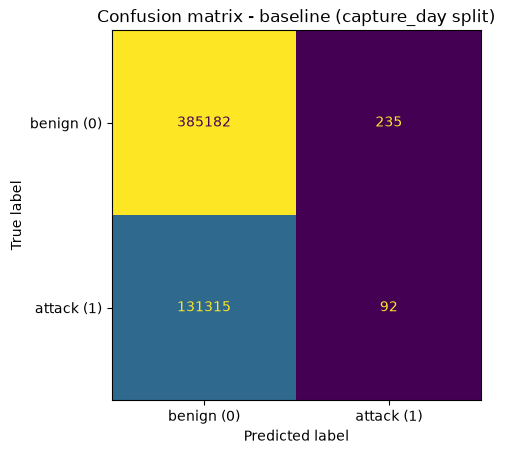

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}")
print(f"FN={fn}  TP={tp}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign (0)", "attack (1)"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix - baseline ({split_method} split)")
plt.tight_layout()
plt.show()

## 6. Precision, Recall, F1

Positive class = attack (`label_binary == 1`). Also reports a full
per-class breakdown against the *original* multiclass label
(`label_multiclass`, if present) -- important for a day-based split,
since aggregate binary metrics can hide that entire attack types were
absent from training.

In [11]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

Precision: 0.2813
Recall   : 0.0007
F1       : 0.0014


In [12]:
if "label_multiclass" in test_df.columns:
    print("Per-class recall breakdown on the test set (day-based splits often")
    print("show 0 recall on attack types absent from the training days -- this")
    print("is expected given the split, not necessarily a modeling failure):\n")
    for cls in sorted(test_df["label_multiclass"].unique()):
        mask = test_df["label_multiclass"] == cls
        if mask.sum() == 0:
            continue
        cls_recall = recall_score(y_test[mask], y_pred[mask], zero_division=0) if cls != "BENIGN" else None
        n_in_train = int((train_df.get("label_multiclass", pd.Series(dtype=object)) == cls).sum())
        print(f"  {cls:20s} n_test={mask.sum():5d}  n_in_train={n_in_train:5d}  recall={cls_recall}")
else:
    print("label_multiclass not present in test_df - skipping per-class breakdown.")

Per-class recall breakdown on the test set (day-based splits often
show 0 recall on attack types absent from the training days -- this
is expected given the split, not necessarily a modeling failure):

  Benign               n_test=385417  n_in_train=1591901  recall=0.0
  Bot                  n_test= 1437  n_in_train=    0  recall=0.0
  DDoS                 n_test=128014  n_in_train=    0  recall=0.00020310278563282142
  PortScan             n_test= 1956  n_in_train=    0  recall=0.03374233128834356


## 7. ROC-AUC and PR-AUC

In [13]:
try:
    roc_auc = roc_auc_score(y_test, y_proba)
except ValueError as exc:
    roc_auc = float("nan")
    print(f"ROC-AUC could not be computed: {exc}")

try:
    pr_auc = average_precision_score(y_test, y_proba)
except ValueError as exc:
    pr_auc = float("nan")
    print(f"PR-AUC could not be computed: {exc}")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

ROC-AUC: 0.9695
PR-AUC : 0.9101


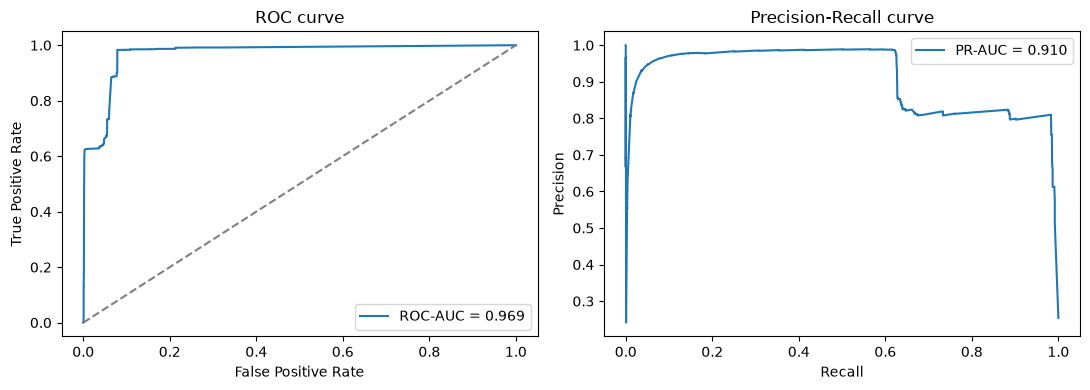

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr_curve, tpr_curve, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. False Positive Rate / False Negative Rate

In [15]:
fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
fnr = fn / (fn + tp) if (fn + tp) > 0 else float("nan")

print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")

False Positive Rate: 0.0006
False Negative Rate: 0.9993


## 9. Feature importance

Gini-based feature importances from the fitted `RandomForestClassifier`
-- not a substitute for SHAP/explainability work, which is explicitly
out of Day 1 scope.

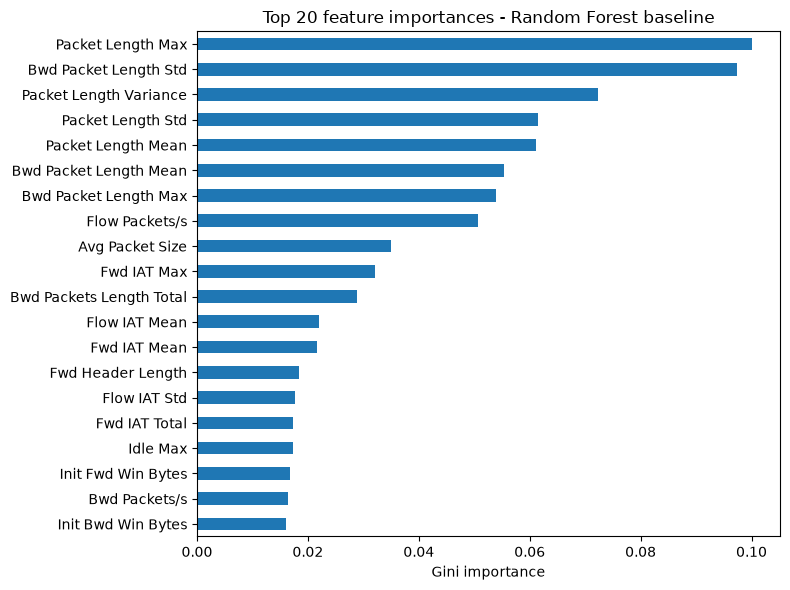

Packet Length Max           0.100126
Bwd Packet Length Std       0.097290
Packet Length Variance      0.072273
Packet Length Std           0.061462
Packet Length Mean          0.061202
Bwd Packet Length Mean      0.055361
Bwd Packet Length Max       0.053883
Flow Packets/s              0.050631
Avg Packet Size             0.034910
Fwd IAT Max                 0.032136
Bwd Packets Length Total    0.028931
Flow IAT Mean               0.022021
Fwd IAT Mean                0.021677
Fwd Header Length           0.018422
Flow IAT Std                0.017588
Fwd IAT Total               0.017399
Idle Max                    0.017330
Init Fwd Win Bytes          0.016848
Bwd Packets/s               0.016424
Init Bwd Win Bytes          0.016058
dtype: float64

In [16]:
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_n.iloc[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 feature importances - Random Forest baseline")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()

top_n

## 10. Saving the baseline model and documenting the split used

Mirrors `scripts/train_baseline.py`'s output locations
(`models/day1/random_forest_baseline.joblib`,
`results/day1/baseline_metrics.json`), and additionally records
`split_method` and the day/timestamp summary actually used, so results
are never separated from the methodology that produced them.

In [17]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics = {
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "false_positive_rate": float(fpr),
    "false_negative_rate": float(fnr),
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "split_method": split_method,
    "split_summary": metadata.get("split_summary"),
}

model_path = MODELS_DIR / "random_forest_baseline.joblib"
joblib.dump(clf, model_path)
print(f"Saved model -> {model_path}")

model_metadata = {
    "model_type": "RandomForestClassifier",
    "hyperparameters": {
        "n_estimators": N_ESTIMATORS,
        "max_depth": MAX_DEPTH,
        "random_state": RANDOM_STATE,
        "class_weight": "balanced",
    },
    "feature_names": feature_names,
    "label_col": "label_binary",
    "split_method": split_method,
    "split_summary": metadata.get("split_summary"),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "train_seconds": train_seconds,
    "nan_imputation": {
        "strategy": "train-median",
        "train_nans_before_impute": n_nan_train,
        "test_nans_before_impute": n_nan_test,
    },
}
(MODELS_DIR / "random_forest_baseline_metadata.json").write_text(
    json.dumps(model_metadata, indent=2, default=str)
)

results_path = RESULTS_DIR / "baseline_metrics.json"
results_path.write_text(json.dumps(metrics, indent=2, default=str))
print(f"Saved evaluation metrics -> {results_path}")

metrics

Saved model -> c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\models\day1\random_forest_baseline.joblib
Saved evaluation metrics -> c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\results\day1\baseline_metrics.json


{'precision': 0.28134556574923547,
 'recall': 0.0007001149101646031,
 'f1': 0.0013967540650097925,
 'roc_auc': 0.9694697874913232,
 'pr_auc': 0.9100762369430839,
 'false_positive_rate': 0.0006097292023963654,
 'false_negative_rate': 0.9992998850898354,
 'confusion_matrix': {'tn': 385182, 'fp': 235, 'fn': 131315, 'tp': 92},
 'split_method': 'capture_day',
 'split_summary': {'day_column': 'capture_day',
  'train_days': ['monday', 'tuesday', 'wednesday', 'thursday'],
  'test_days': ['friday'],
  'train_rows': 1796986,
  'test_rows': 516824}}

## Summary

* Loaded the train/test split and **confirmed** (via `split_method` in
  the metadata) that it was produced by day-based splitting, not
  row-level timestamps -- consistent with the finding in
  `03_temporal_split.ipynb` that this dataset variant has no timestamp
  column.
* Verified `capture_day` never leaked into the model's feature set.
* Trained the same lightweight Random Forest baseline as
  `scripts/train_baseline.py`.
* Reported confusion matrix, Precision/Recall/F1 (aggregate **and**
  per-attack-type, to surface day-specific class-distribution effects),
  ROC-AUC/PR-AUC, FPR/FNR, and feature importance.
* Saved the model and metrics, together with the split method that
  produced them, so results are never separated from their methodology.

**Takeaway carried forward:** any recall/precision numbers from this
notebook reflect a day-based, not row-level, temporal split. Do not
compare them directly against a hypothetical row-level-timestamp
baseline without noting that difference.